<a href="https://colab.research.google.com/github/SalomeAc/Redes-Entrega1/blob/main/Copy_of_FirstDeliveryProyect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("indk214/brain-tumor-dataset-segmentation-and-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-dataset-segmentation-and-classification' dataset.
Path to dataset files: /kaggle/input/brain-tumor-dataset-segmentation-and-classification


In [ ]:
plt.style.use('ggplot')
sns.set_palette("husl")

## Load Data

In [ ]:
data_path = "/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/classification/Training"

images = []
labels = []
img_sizes = []
img_modes = []

for subfolder in os.listdir(data_path):
    subfolder_path = os.path.join(data_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)

        with Image.open(image_path) as img:
            img_sizes.append(img.size)
            img_modes.append(img.mode)

        images.append(image_path)
        labels.append(subfolder)

data = pd.DataFrame({'image_path': images, 'label': labels, 'image_size': img_sizes, 'image_mode': img_modes})

In [ ]:
def display_sample_images(data):
    sampled_data = data.groupby('label').apply(lambda x: x.sample(1)).reset_index(drop=True)

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle('Sample Brain MRI Images (1 per class)', fontsize=16, fontweight='bold')

    for idx, (_, row) in enumerate(sampled_data.iterrows()):
        ax = axes[idx // 2, idx % 2]
        img = Image.open(row['image_path'])
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Class: {row['label']}\nSize: {img.size}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Data set overview

In [ ]:
print("Dataset Overview:")
print(f"Total images: {len(data)}")
print(f"Classes: {data['label'].unique()}")
print(f"Class distribution:\n{data['label'].value_counts()}")
print(f"Image modes: {data['image_mode'].value_counts()}")
print(f"Unique image sizes: {data['image_size'].value_counts().head(5)}")


Dataset Overview:
Total images: 5712
Classes: ['pituitary' 'notumor' 'meningioma' 'glioma']
Class distribution:
label
notumor       1595
pituitary     1457
meningioma    1339
glioma        1321
Name: count, dtype: int64
Image modes: image_mode
L    5712
Name: count, dtype: int64
Unique image sizes: image_size
(512, 512)    3955
(225, 225)     268
(630, 630)      77
(236, 236)      53
(201, 251)      43
Name: count, dtype: int64


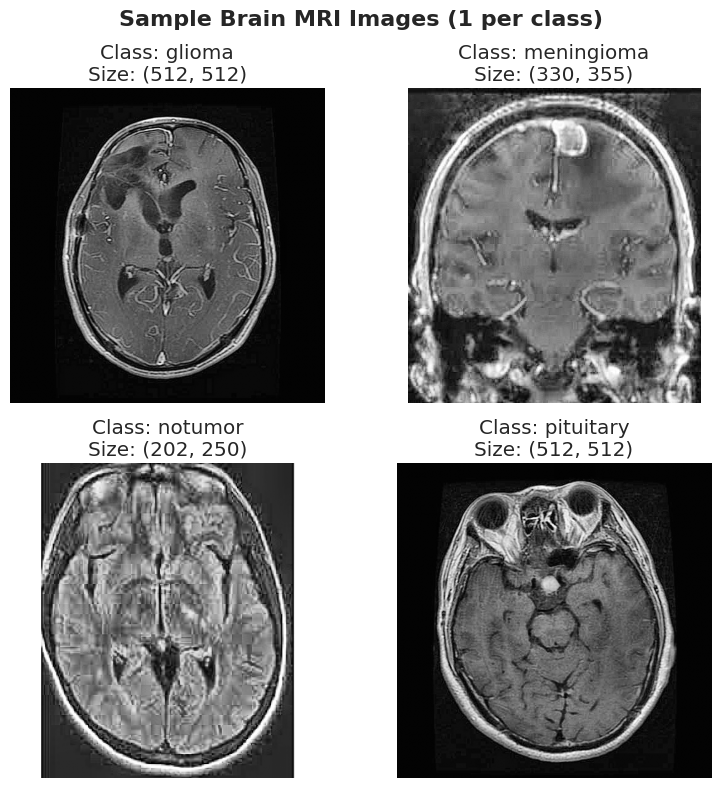

In [ ]:
display_sample_images(data)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score, cohen_kappa_score, matthews_corrcoef,
                             log_loss, balanced_accuracy_score, jaccard_score,
                             hamming_loss, zero_one_loss)
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                    Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import to_categorical

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
data_path = "/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/classification/Training"

images = []
labels = []
img_arrays = []

for subfolder in os.listdir(data_path):
    subfolder_path = os.path.join(data_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)

        img = Image.open(image_path).convert('L')
        img = img.resize((128, 128))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=-1)

        images.append(image_path)
        labels.append(subfolder)
        img_arrays.append(img_array)

In [ ]:
data = pd.DataFrame({'image_path': images, 'label': labels})
X = np.array(img_arrays)
y = np.array(labels)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2,
                                                    stratify=y_encoded, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                                  stratify=y_train, random_state=42)

y_train_cat = to_categorical(y_train, num_classes=len(le.classes_))
y_val_cat = to_categorical(y_val, num_classes=len(le.classes_))
y_test_cat = to_categorical(y_test, num_classes=len(le.classes_))

print(f"Training set: {X_train.shape}, {y_train_cat.shape}")
print(f"Validation set: {X_val.shape}, {y_val_cat.shape}")
print(f"Test set: {X_test.shape}, {y_test_cat.shape}")
print(f"Classes: {le.classes_}")

Training set: (3655, 128, 128, 1), (3655, 4)
Validation set: (914, 128, 128, 1), (914, 4)
Test set: (1143, 128, 128, 1), (1143, 4)
Classes: ['glioma' 'meningioma' 'notumor' 'pituitary']


# Data augmentation and class weights balance

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.081360946745562), 1: np.float64(1.0662193698949824), 2: np.float64(0.8949559255631734), 3: np.float64(0.9804184549356223)}


# Model CNN Architecture

In [ ]:
model = Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(128, 128, 1)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
Dropout(0.2)

model.add(Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
Dropout(0.5)


model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dropout(0.3))

model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))
model.add(Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))


model.add(Dense(4, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))



model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,052 (6.02 MB)

 Trainable params: 1,577,092 (6.02 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# callbacks

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=30,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights,
    verbose=2
)

Epoch 1/30


114/114 - 104s - 910ms/step - accuracy: 0.6064 - loss: 1.0327 - val_accuracy: 0.2549 - val_loss: 3.3895 - learning_rate: 0.0010
Epoch 2/30
114/114 - 6s - 55ms/step - accuracy: 0.8750 - loss: 0.4854 - val_accuracy: 0.2549 - val_loss: 3.6719 - learning_rate: 0.0010
Epoch 3/30
114/114 - 93s - 815ms/step - accuracy: 0.7312 - loss: 0.7619 - val_accuracy: 0.2549 - val_loss: 4.6168 - learning_rate: 0.0010
Epoch 4/30
114/114 - 6s - 56ms/step - accuracy: 0.6875 - loss: 0.8740 - val_accuracy: 0.2549 - val_loss: 4.1443 - learning_rate: 0.0010
Epoch 5/30


114/114 - 96s - 846ms/step - accuracy: 0.7673 - loss: 0.6689 - val_accuracy: 0.2867 - val_loss: 4.2301 - learning_rate: 0.0010
Epoch 6/30


114/114 - 7s - 57ms/step - accuracy: 0.8438 - loss: 0.5284 - val_accuracy: 0.2965 - val_loss: 4.1330 - learning_rate: 0.0010
Epoch 7/30


114/114 - 96s - 839ms/step - accuracy: 0.8153 - loss: 0.5466 - val_accuracy: 0.3414 - val_loss: 4.5482 - learning_rate: 2.0000e-04
Epoch 8/30


...

114/114 - 131s - 1s/step - accuracy: 0.8396 - loss: 0.4746 - val_accuracy: 0.7549 - val_loss: 0.7223 - learning_rate: 2.0000e-04
Epoch 14/30


114/114 - 11s - 97ms/step - accuracy: 0.9375 - loss: 0.3128 - val_accuracy: 0.7582 - val_loss: 0.7230 - learning_rate: 2.0000e-04
Epoch 15/30


114/114 - 90s - 790ms/step - accuracy: 0.8592 - loss: 0.4398 - val_accuracy: 0.7812 - val_loss: 0.7038 - learning_rate: 2.0000e-04
Epoch 16/30
114/114 - 6s - 57ms/step - accuracy: 0.9375 - loss: 0.2719 - val_accuracy: 0.7702 - val_loss: 0.7327 - learning_rate: 2.0000e-04
Epoch 17/30


114/114 - 136s - 1s/step - accuracy: 0.8661 - loss: 0.4184 - val_accuracy: 0.8173 - val_loss: 0.6123 - learning_rate: 2.0000e-04
Epoch 18/30


114/114 - 11s - 97ms/step - accuracy: 0.8750 - loss: 0.2819 - val_accuracy: 0.8260 - val_loss: 0.5944 - learning_rate: 2.0000e-04
Epoch 19/30
114/114 - 89s - 782ms/step - accuracy: 0.8730 - loss: 0.4040 - val_accuracy: 0.6991 - val_loss: 0.9871 - learning_rate: 2.0000e-04
Epoch 20/30
114/114 - 11s - 96ms/step - accuracy: 0.6875 - loss: 0.7843 - val_accuracy: 0.7210 - val_loss: 0.8973 - learning_rate: 2.0000e-04
Epoch 21/30
114/114 - 91s - 801ms/step - accuracy: 0.8717 - loss: 0.4022 - val_accuracy: 0.7232 - val_loss: 1.0054 - learning_rate: 2.0000e-04
Epoch 22/30
114/114 - 11s - 96ms/step - accuracy: 0.8438 - loss: 0.3532 - val_accuracy: 0.7276 - val_loss: 0.9651 - learning_rate: 2.0000e-04
Epoch 23/30
114/114 - 138s - 1s/step - accuracy: 0.8766 - loss: 0.3908 - val_accuracy: 0.8042 - val_loss: 0.5972 - learning_rate: 2.0000e-04
Epoch 24/30
114/114 - 7s - 60ms/step - accuracy: 0.8750 - loss: 0.3820 - val_accuracy: 0.8031 - val_loss: 0.5948 - learning_rate: 4.0000e-05
Epoch 25/30
114/11

In [ ]:
model.load_weights('best_model.h5')

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8058
Test Loss: 0.6317


In [ ]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

y_test_true = y_test

36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step


In [ ]:
metrics = {}

metrics['Accuracy'] = accuracy_score(y_test_true, y_pred)
metrics['Precision (Macro)'] = precision_score(y_test_true, y_pred, average='macro')
metrics['Recall (Macro)'] = recall_score(y_test_true, y_pred, average='macro')
metrics['F1-Score (Macro)'] = f1_score(y_test_true, y_pred, average='macro')
metrics['Precision (Micro)'] = precision_score(y_test_true, y_pred, average='micro')
metrics['Recall (Micro)'] = recall_score(y_test_true, y_pred, average='micro')
metrics['F1-Score (Micro)'] = f1_score(y_test_true, y_pred, average='micro')
metrics['Precision (Weighted)'] = precision_score(y_test_true, y_pred, average='weighted')
metrics['Recall (Weighted)'] = recall_score(y_test_true, y_pred, average='weighted')
metrics['F1-Score (Weighted)'] = f1_score(y_test_true, y_pred, average='weighted')

metrics['Cohen Kappa Score'] = cohen_kappa_score(y_test_true, y_pred)
metrics['Matthews Correlation Coefficient'] = matthews_corrcoef(y_test_true, y_pred)
metrics['Balanced Accuracy'] = balanced_accuracy_score(y_test_true, y_pred)
metrics['Jaccard Score (Macro)'] = jaccard_score(y_test_true, y_pred, average='macro')
metrics['Hamming Loss'] = hamming_loss(y_test_true, y_pred)
metrics['Zero-One Loss'] = zero_one_loss(y_test_true, y_pred)

In [ ]:
num_classes=4

y_test_bin = to_categorical(y_test_true, num_classes=num_classes)

roc_auc_scores = []
pr_auc_scores = []


for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_scores.append(auc(fpr, tpr))

    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc_scores.append(average_precision_score(y_test_bin[:, i], y_pred_proba[:, i]))

metrics['ROC AUC (Macro)'] = np.mean(roc_auc_scores)
metrics['PR AUC (Macro)'] = np.mean(pr_auc_scores)

metrics['Log Loss'] = log_loss(y_test_bin, y_pred_proba)

metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print("\nEvaluation Metrics:")
print(metrics_df.round(4))


Evaluation Metrics:
                              Metric   Value
0                           Accuracy  0.8058
1                  Precision (Macro)  0.8303
2                     Recall (Macro)  0.7937
3                   F1-Score (Macro)  0.7933
4                  Precision (Micro)  0.8058
5                     Recall (Micro)  0.8058
6                   F1-Score (Micro)  0.8058
7               Precision (Weighted)  0.8267
8                  Recall (Weighted)  0.8058
9                F1-Score (Weighted)  0.7982
10                 Cohen Kappa Score  0.7389
11  Matthews Correlation Coefficient  0.7496
12                 Balanced Accuracy  0.7937
13             Jaccard Score (Macro)  0.6660
14                      Hamming Loss  0.1942
15                     Zero-One Loss  0.1942
16                   ROC AUC (Macro)  0.9601
17                    PR AUC (Macro)  0.8981
18                          Log Loss  0.5678


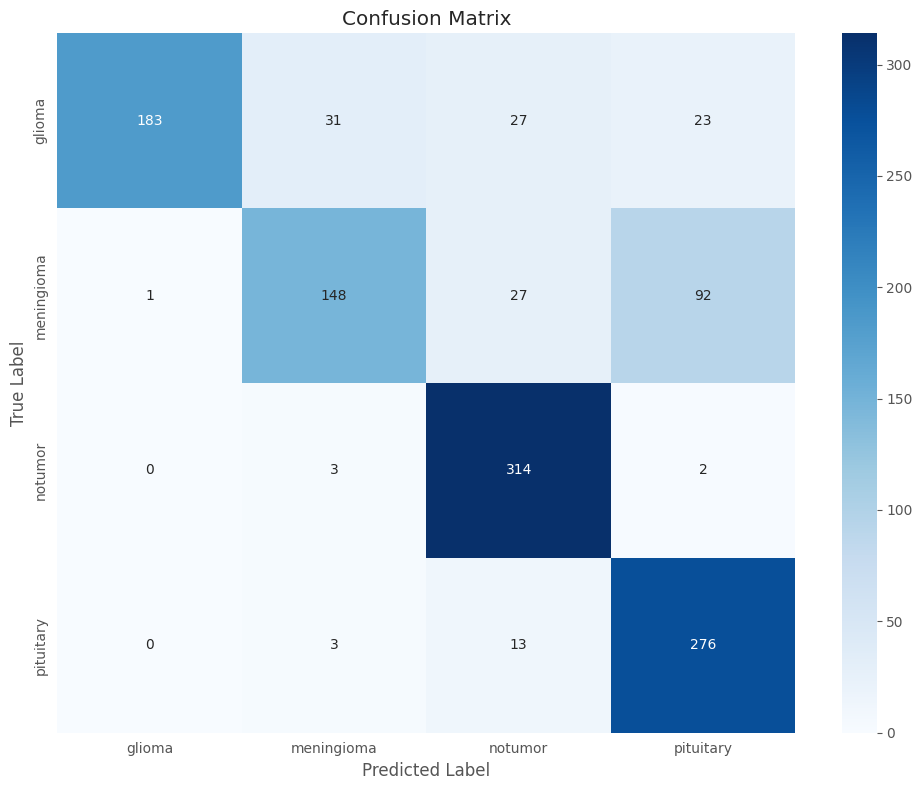

In [ ]:
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test_true, y_pred, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.69      0.82       264
  meningioma       0.80      0.55      0.65       268
     notumor       0.82      0.98      0.90       319
   pituitary       0.70      0.95      0.81       292

    accuracy                           0.81      1143
   macro avg       0.83      0.79      0.79      1143
weighted avg       0.83      0.81      0.80      1143



# Model MLP Architecture

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# We assume your MRI images have been resized to 128x128 pixels and are grayscale (1 channel).
# Change this if your images are RGB (128, 128, 3) or a different size.
INPUT_SHAPE = (128, 128, 1)

# Building the MLP Classification Model directly using Sequential
model = Sequential([
    # 1. Input layer: Flatten the 2D image array into a 1D vector
    Flatten(input_shape=INPUT_SHAPE),

    # 2. First Hidden Block
    # Using L2 regularization to keep the neural weights from growing too large
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5), # Dropping 50% of connections to prevent memorization

    # 3. Second Hidden Block
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),

    # 4. Third Hidden Block
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    # 5. Output Layer: Exactly 4 neurons for your 4 brain tumor classes
    # Softmax ensures the outputs are probabilities that sum to 1
    Dense(4, activation='softmax')
])

# View the architecture and the parameter count
model.summary()

# Compiling the model for multi-class classification
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Slightly lower learning rate for MLPs
    loss='categorical_crossentropy', # Use 'sparse_categorical_crossentropy' if your labels are integers (0,1,2,3)
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,442,564 (66.54 MB)

 Trainable params: 17,438,980 (66.52 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=30,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights,
    verbose=2
)

Epoch 1/30


114/114 - 68s - 595ms/step - accuracy: 0.4033 - loss: 4.4743 - val_accuracy: 0.2768 - val_loss: 7.7637 - learning_rate: 5.0000e-04
Epoch 2/30
114/114 - 4s - 31ms/step - accuracy: 0.4062 - loss: 4.1977 - val_accuracy: 0.2768 - val_loss: 7.7464 - learning_rate: 5.0000e-04
Epoch 3/30


114/114 - 59s - 514ms/step - accuracy: 0.4604 - loss: 3.9107 - val_accuracy: 0.4333 - val_loss: 3.6541 - learning_rate: 5.0000e-04
Epoch 4/30
114/114 - 2s - 22ms/step - accuracy: 0.5000 - loss: 3.9105 - val_accuracy: 0.4278 - val_loss: 3.6782 - learning_rate: 5.0000e-04
Epoch 5/30


114/114 - 80s - 704ms/step - accuracy: 0.4546 - loss: 3.6060 - val_accuracy: 0.5635 - val_loss: 3.1196 - learning_rate: 5.0000e-04
Epoch 6/30


114/114 - 5s - 46ms/step - accuracy: 0.4688 - loss: 3.5511 - val_accuracy: 0.5744 - val_loss: 3.1068 - learning_rate: 5.0000e-04
Epoch 7/30
114/114 - 59s - 515ms/step - accuracy: 0.4910 - loss: 3.2461 - val_accuracy: 0.5241 - val_loss: 2.9342 - learning_rate: 5.0000e-04
Epoch 8/30
114/114 - 3s - 26ms/step - accuracy: 0.5938 - loss: 3.1307 - val_accuracy: 0.5284 - val_loss: 2.9370 - learning_rate: 5.0000e-04
Epoch 9/30


114/114 - 81s - 707ms/step - accuracy: 0.5115 - loss: 2.9790 - val_accuracy: 0.6258 - val_loss: 2.5952 - learning_rate: 5.0000e-04
Epoch 10/30


114/114 - 3s - 28ms/step - accuracy: 0.4062 - loss: 3.0009 - val_accuracy: 0.6269 - val_loss: 2.5961 - learning_rate: 5.0000e-04
Epoch 11/30
114/114 - 70s - 617ms/step - accuracy: 0.5156 - loss: 2.7604 - val_accuracy: 0.6214 - val_loss: 2.4231 - learning_rate: 5.0000e-04
Epoch 12/30


114/114 - 4s - 35ms/step - accuracy: 0.4688 - loss: 2.8022 - val_accuracy: 0.6291 - val_loss: 2.4160 - learning_rate: 5.0000e-04
Epoch 13/30
114/114 - 60s - 530ms/step - accuracy: 0.5261 - loss: 2.5852 - val_accuracy: 0.5427 - val_loss: 2.4684 - learning_rate: 5.0000e-04
Epoch 14/30
114/114 - 6s - 51ms/step - accuracy: 0.5312 - loss: 2.4327 - val_accuracy: 0.5317 - val_loss: 2.4984 - learning_rate: 5.0000e-04
Epoch 15/30
114/114 - 79s - 690ms/step - accuracy: 0.5173 - loss: 2.4483 - val_accuracy: 0.5580 - val_loss: 2.2431 - learning_rate: 5.0000e-04
Epoch 16/30
114/114 - 3s - 23ms/step - accuracy: 0.6562 - loss: 2.1841 - val_accuracy: 0.5591 - val_loss: 2.2378 - learning_rate: 5.0000e-04
Epoch 17/30
114/114 - 60s - 525ms/step - accuracy: 0.5266 - loss: 2.3089 - val_accuracy: 0.6269 - val_loss: 2.0436 - learning_rate: 5.0000e-04
Epoch 18/30
114/114 - 4s - 34ms/step - accuracy: 0.5625 - loss: 2.2277 - val_accuracy: 0.6247 - val_loss: 2.0441 - learning_rate: 5.0000e-04
Epoch 19/30


114/114 - 86s - 750ms/step - accuracy: 0.5333 - loss: 2.1935 - val_accuracy: 0.6324 - val_loss: 1.9332 - learning_rate: 5.0000e-04
Epoch 20/30
114/114 - 3s - 29ms/step - accuracy: 0.5000 - loss: 2.1479 - val_accuracy: 0.6324 - val_loss: 1.9335 - learning_rate: 5.0000e-04
Epoch 21/30
114/114 - 72s - 631ms/step - accuracy: 0.5380 - loss: 2.1143 - val_accuracy: 0.5996 - val_loss: 1.9327 - learning_rate: 5.0000e-04
Epoch 22/30
114/114 - 3s - 23ms/step - accuracy: 0.5000 - loss: 1.9788 - val_accuracy: 0.6028 - val_loss: 1.9268 - learning_rate: 5.0000e-04
Epoch 23/30
114/114 - 80s - 699ms/step - accuracy: 0.5393 - loss: 2.0344 - val_accuracy: 0.6204 - val_loss: 1.8294 - learning_rate: 5.0000e-04
Epoch 24/30
114/114 - 3s - 27ms/step - accuracy: 0.5000 - loss: 1.9586 - val_accuracy: 0.6214 - val_loss: 1.8271 - learning_rate: 5.0000e-04
Epoch 25/30
114/114 - 62s - 545ms/step - accuracy: 0.5518 - loss: 1.9515 - val_accuracy: 0.6039 - val_loss: 1.7822 - learning_rate: 5.0000e-04
Epoch 26/30
114/1

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.6002
Test Loss: 1.6838


In [ ]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

y_test_true = y_test

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step


In [ ]:
metrics = {}

metrics['Accuracy'] = accuracy_score(y_test_true, y_pred)
metrics['Precision (Macro)'] = precision_score(y_test_true, y_pred, average='macro')
metrics['Recall (Macro)'] = recall_score(y_test_true, y_pred, average='macro')
metrics['F1-Score (Macro)'] = f1_score(y_test_true, y_pred, average='macro')
metrics['Precision (Micro)'] = precision_score(y_test_true, y_pred, average='micro')
metrics['Recall (Micro)'] = recall_score(y_test_true, y_pred, average='micro')
metrics['F1-Score (Micro)'] = f1_score(y_test_true, y_pred, average='micro')
metrics['Precision (Weighted)'] = precision_score(y_test_true, y_pred, average='weighted')
metrics['Recall (Weighted)'] = recall_score(y_test_true, y_pred, average='weighted')
metrics['F1-Score (Weighted)'] = f1_score(y_test_true, y_pred, average='weighted')

metrics['Cohen Kappa Score'] = cohen_kappa_score(y_test_true, y_pred)
metrics['Matthews Correlation Coefficient'] = matthews_corrcoef(y_test_true, y_pred)
metrics['Balanced Accuracy'] = balanced_accuracy_score(y_test_true, y_pred)
metrics['Jaccard Score (Macro)'] = jaccard_score(y_test_true, y_pred, average='macro')
metrics['Hamming Loss'] = hamming_loss(y_test_true, y_pred)
metrics['Zero-One Loss'] = zero_one_loss(y_test_true, y_pred)

In [ ]:
num_classes=4

y_test_bin = to_categorical(y_test_true, num_classes=num_classes)

roc_auc_scores = []
pr_auc_scores = []


for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_scores.append(auc(fpr, tpr))

    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc_scores.append(average_precision_score(y_test_bin[:, i], y_pred_proba[:, i]))

metrics['ROC AUC (Macro)'] = np.mean(roc_auc_scores)
metrics['PR AUC (Macro)'] = np.mean(pr_auc_scores)

metrics['Log Loss'] = log_loss(y_test_bin, y_pred_proba)

metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print("\nEvaluation Metrics:")
print(metrics_df.round(4))


Evaluation Metrics:
                              Metric   Value
0                           Accuracy  0.6002
1                  Precision (Macro)  0.6386
2                     Recall (Macro)  0.6037
3                   F1-Score (Macro)  0.5832
4                  Precision (Micro)  0.6002
5                     Recall (Micro)  0.6002
6                   F1-Score (Micro)  0.6002
7               Precision (Weighted)  0.6450
8                  Recall (Weighted)  0.6002
9                F1-Score (Weighted)  0.5833
10                 Cohen Kappa Score  0.4679
11  Matthews Correlation Coefficient  0.4878
12                 Balanced Accuracy  0.6037
13             Jaccard Score (Macro)  0.4187
14                      Hamming Loss  0.3998
15                     Zero-One Loss  0.3998
16                   ROC AUC (Macro)  0.8615
17                    PR AUC (Macro)  0.6740
18                          Log Loss  0.9351


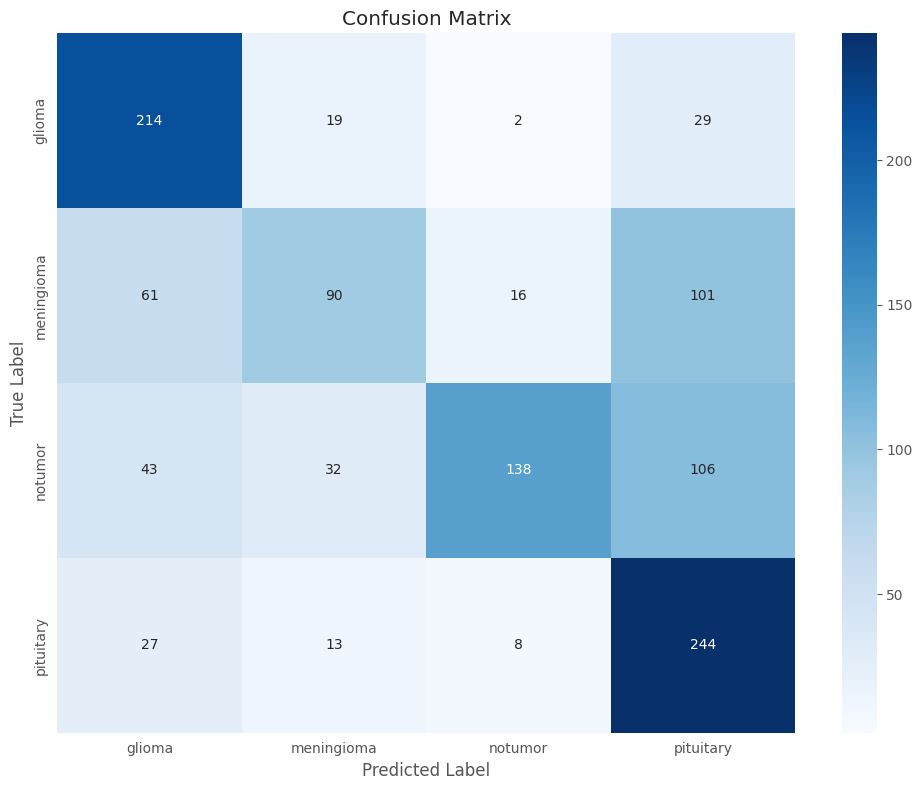

In [ ]:
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()